In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import movie_reviews, stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
for pkg in ["movie_reviews", "punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)

In [3]:
docs = [(movie_reviews.raw(fileid), category)
        for category in movie_reviews.categories()
        for fileid in movie_reviews.fileids(category)]

df = pd.DataFrame(docs, columns=["review", "label"])
df.head()

,review,label
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


In [4]:
print("Shape:", df.shape)
print("Class balance:\n", df["label"].value_counts())
print("Missing values:", df.isnull().sum().sum())
print("Duplicate reviews:", df.duplicated().sum())

Shape: (2000, 2)
Class balance:
 label
neg    1000
pos    1000
Name: count, dtype: int64
Missing values: 0
Duplicate reviews: 0


In [5]:
stop_words = set(stopwords.words("english"))
negations = {"no", "not", "nor", "n't", "never", "none", "cannot"}
custom_stopwords = stop_words - negations

In [6]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [7]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # strip HTML tags (e.g. <br>)
    text = re.sub(r"[^a-z\s]", " ", text)        # strip punctuation/numbers
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in custom_stopwords and len(t) > 1]
    tagged = pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(w, get_wordnet_pos(tag)) for w, tag in tagged]
    return " ".join(lemmas)

print(df["review"].iloc[0][:200])
print("--->")
print(preprocess(df["review"].iloc[0][:200]))

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
w
--->
plot two teen couple go church party drink drive get accident one guy die girlfriend continue see life nightmare


In [8]:
df["clean_review"] = df["review"].apply(preprocess)
df[["label", "clean_review"]].head()

,label,clean_review
0,neg,plot two teen couple go church party drink dri...
1,neg,happy bastard quick movie review damn bug get ...
2,neg,movie like make jaded movie viewer thankful in...
3,neg,quest camelot warner bros first feature length...
4,neg,synopsis mentally unstable man undergo psychot...


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"], df["label"],
    test_size=0.2, stratify=df["label"], random_state=RANDOM_STATE
)
print("Train size:", len(X_train), "| Test size:", len(X_test))

Train size: 1600 | Test size: 400


In [10]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2)),
    ("clf", MultinomialNB(alpha=1.0)),
])
nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)
print("Naive Bayes accuracy:", round(accuracy_score(y_test, nb_preds), 4))
print(classification_report(y_test, nb_preds))

Naive Bayes accuracy: 0.8225
              precision    recall  f1-score   support

         neg       0.81      0.84      0.83       200
         pos       0.83      0.81      0.82       200

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



In [11]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2)),
    ("clf", LinearSVC(random_state=RANDOM_STATE)),
])
svm_pipeline.fit(X_train, y_train)
svm_preds = svm_pipeline.predict(X_test)
print("SVM accuracy:", round(accuracy_score(y_test, svm_preds), 4))
print(classification_report(y_test, svm_preds))

SVM accuracy: 0.8325
              precision    recall  f1-score   support

         neg       0.86      0.80      0.83       200
         pos       0.81      0.86      0.84       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



                     Model  Accuracy
0  Multinomial Naive Bayes    0.8225
1               Linear SVM    0.8325


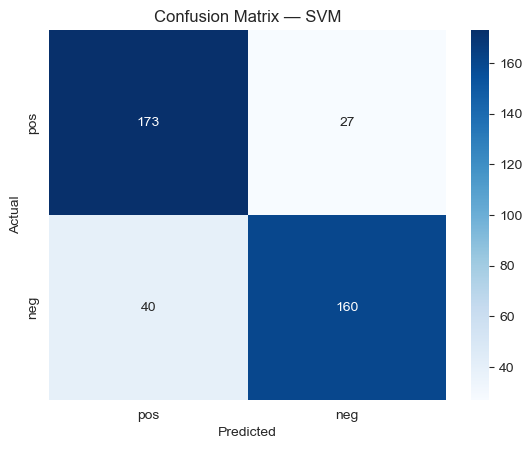

In [12]:
results = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Linear SVM"],
    "Accuracy": [accuracy_score(y_test, nb_preds), accuracy_score(y_test, svm_preds)],
})
print(results)

best_preds = svm_preds if results.iloc[1]["Accuracy"] >= results.iloc[0]["Accuracy"] else nb_preds
best_name = "SVM" if results.iloc[1]["Accuracy"] >= results.iloc[0]["Accuracy"] else "Naive Bayes"

cm = confusion_matrix(y_test, best_preds, labels=["pos", "neg"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["pos", "neg"], yticklabels=["pos", "neg"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix — {best_name}")
plt.show()

In [13]:
best_pipeline = svm_pipeline if best_name == "SVM" else nb_pipeline
joblib.dump(best_pipeline, "sentiment_analysis_best_model.joblib")
print("Saved:", best_name)

Saved: SVM


In [14]:
new_reviews = [
    "This product exceeded my expectations, I absolutely love it!",
    "Terrible quality, it broke after one day and I am not happy at all.",
]
loaded_model = joblib.load("sentiment_analysis_best_model.joblib")
preds = loaded_model.predict([preprocess(r) for r in new_reviews])

for review, pred in zip(new_reviews, preds):
    print(f"[{pred}] {review}")

[pos] This product exceeded my expectations, I absolutely love it!
[neg] Terrible quality, it broke after one day and I am not happy at all.
